<font color = green >

## Home Task
</font>

<font color = green>

### Brest Cancer Dataset

</font>



In [1]:
# https://scikit-learn.org/stable/datasets/index.html#breast-cancer-dataset
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y= True)
print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)

X.shape=  (569, 30)
y.shape=  (569,)


In [2]:
# YOUR_CODE.  Preproces data, train classifier and evaluate the perfromance on train and test sets 
# START_CODE 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test  =  train_test_split(X, y, random_state= 0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf= MLPClassifier(
    solver= 'adam',
    hidden_layer_sizes= (100,),
    alpha=0.0001,
    max_iter= 10000
).fit(X_train_scaled, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled, y_test)))
# END_CODE 
    

train accuracy= 99.765%
test accuracy= 97.203%


# ........
try to use use scikit-learn best practices, Pipeline, GridSearchCV, etc.
Also try other metrics: f1_score, roc_auc_score, recall_score, precision_score
And as in lecture 4, find a best parameters for MLP

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test  =  train_test_split(X, y, random_state= 0)

import pandas as pd

mlp_pipeline = GridSearchCV(
    estimator = Pipeline(
        [
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(random_state=0, max_iter=10000))
        ]
), 
    param_grid = {
        "mlp__hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "mlp__activation":         ["relu", "identity", "tanh"],
        "mlp__alpha":              [0.0001, 0.01, 1.0],
        "mlp__solver":             ["lbfgs", "adam"]
        }, 
        n_jobs=-1, # use all available cores
        verbose=0, # no output during fitting
        refit=True # refit best model on full X_train
)
mlp_pipeline.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu', 'identity', ...], 'mlp__alpha': [0.0001, 0.01, ...], 'mlp__hidden_layer_sizes': [(50,), (100,), ...], 'mlp__solver': ['lbfgs', 'adam']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the 

function to print grid search results(saw in lecture 4) and metrics for a model


In [4]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score

def print_grid_search_results(model, X_train, y_train,X_test, y_test) -> pd.DataFrame:
    '''
    Print hyperparameters and key metrics for a fitted model.
    Supports both GridSearchCV and plain estimators (e.g., Pipeline, MLPClassifier).
    Supports both binary and multiclass classification.

    prev version supported only binary classification
    so with modern tool i refactor it
    and add support for multiclass classification and more metrics.
    '''
    pred = model.predict(X_test)
    n_classes = len(np.unique(y_test))

    # If GridSearchCV is used, show best params. Otherwise show selected MLP params.
    if hasattr(model, "best_params_"):
        params_source = model.best_params_
    else:
        params_source = {
            k: v for k, v in model.get_params().items()
            if k.startswith("mlp__") and "__" not in k[5:]
        }

    if params_source:
        params_df = pd.DataFrame([
            {"parameter": k.replace("mlp__", ""), "best_value": v}
            for k, v in params_source.items()
        ])
    else:
        params_df = pd.DataFrame([{"parameter": "model", "best_value": type(model).__name__}])

    metrics = []
    if hasattr(model, "best_score_"):
        metrics.append({"metric": "CV Score (train)", "value": model.best_score_})

    metrics.extend([
        {"metric": "Accuracy (train)", "value": model.score(X_train, y_train)},
        {"metric": "Accuracy (test)", "value": model.score(X_test, y_test)},
    ])

    if n_classes == 2:
        metrics.extend([
            {"metric": "F1 Score (test)", "value": f1_score(y_test, pred)},
            {"metric": "Recall (test)", "value": recall_score(y_test, pred, zero_division=0)},
            {"metric": "Precision (test)", "value": precision_score(y_test, pred, zero_division=0)},
        ])
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)[:, 1]
            metrics.append({"metric": "ROC AUC (test)", "value": roc_auc_score(y_test, proba)})
    else: # multiclass classification
        metrics.extend([
            {"metric": "F1 Macro (test)", "value": f1_score(y_test, pred, average="macro", zero_division=0)},
            {"metric": "Recall Macro (test)", "value": recall_score(y_test, pred, average="macro", zero_division=0)},
            {"metric": "Precision Macro (test)", "value": precision_score(y_test, pred, average="macro", zero_division=0)},
        ])
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_test)
            metrics.append({
                "metric": "ROC AUC OVR Weighted (test)",
                "value": roc_auc_score(y_test, proba, multi_class="ovr", average="weighted"),
            })

    metrics_df = pd.DataFrame(metrics)

    print("-" * 40)
    print("Hyperparameters:")
    print(params_df.to_string(index=False))
    print("-" * 40)
    print("Performance Metrics:")
    print(metrics_df.round(4).to_string(index=False))
    print("-" * 40)

    return metrics_df
binary_mlp_metrics = print_grid_search_results(mlp_pipeline, X_train, y_train, X_test, y_test)

----------------------------------------
Hyperparameters:
         parameter best_value
        activation   identity
             alpha     0.0001
hidden_layer_sizes     (100,)
            solver       adam
----------------------------------------
Performance Metrics:
          metric  value
CV Score (train) 0.9836
Accuracy (train) 0.9859
 Accuracy (test) 0.9580
 F1 Score (test) 0.9667
   Recall (test) 0.9667
Precision (test) 0.9667
  ROC AUC (test) 0.9828
----------------------------------------


<font color = green>

##  Signs dataset

</font>



In [5]:
from matplotlib import pyplot as plt
import h5py
import os
path = 'data'

In [6]:
# signs data set (fingers)
def load_dataset():
    fn =  os.path.join(path , 'train_signs.h5')
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn =  os.path.join(path , 'test_signs.h5')
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    y_train = y_train.reshape((1, y_train.shape[0]))
    y_test = y_test.reshape((1, y_test.shape[0]))
    
    return X_train, y_train, X_test, y_test, classes


In [7]:
X_train, y_train, X_test, y_test, classes = load_dataset()
y_train = y_train.ravel()
y_test = y_test.ravel()
print ('X_train.shape=', X_train.shape)
print ('X_test.shape=', X_test.shape)
print ('y_train.shape=', y_train.shape)
print ('y_test.shape=', y_test.shape)

X_train.shape= (1080, 64, 64, 3)
X_test.shape= (120, 64, 64, 3)
y_train.shape= (1080,)
y_test.shape= (120,)


In [8]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None: 
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows): 
        for j in range (n_cols):
            index = n_rows*i+j           
            ax = plt.subplot(n_rows,n_cols,index+1) 
            plt.imshow(X[indices[index]])
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

    plt.tight_layout(h_pad=1)


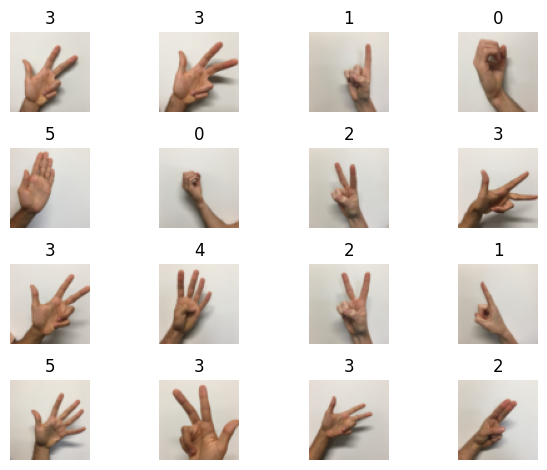

In [9]:
plt.figure()

display_samples_in_grid(X_train, n_rows=4, y= y_train)

In [10]:
#plt.gcf().canvas.set_window_title('Train set') AttributeError

In [11]:
# Not in use 
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)]
    return Y

In [12]:
# YOUR_CODE.  Preproces data
# START_CODE 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))
# END_CODE     

print ("number of training examples = " + str(X_train_scaled.shape[1]))
print ("number of test examples = " + str(X_test_scaled.shape[1]))
print ("X_train_sign_scaled shape: " + str(X_train_scaled.shape))
print ("X_test_sign_scaled shape: " + str(X_test_scaled.shape))

number of training examples = 12288
number of test examples = 12288
X_train_sign_scaled shape: (1080, 12288)
X_test_sign_scaled shape: (120, 12288)


### Expected result 

```
number of training examples = 12288
number of test examples = 12288
X_train_scaled shape: (1080, 12288)
X_test_scaled shape: (120, 12288)
```

In [13]:
%%time
# YOUR_CODE.  Train classifier and evaluate the perfromance on train and test sets 
# START_CODE 
clf= MLPClassifier(
    solver= 'lbfgs',
    hidden_layer_sizes= (100,100),
    random_state = 0,
    max_iter= 2000
).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score(X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled, y_test)))
# END_CODE     

train accuracy= 100.000%
test accuracy= 92.500%
CPU times: user 2.23 s, sys: 217 ms, total: 2.45 s
Wall time: 2.54 s


In [14]:
%%time
# also try to use pipeline and grid search to find the best hyperparameters (can be slow)
# and evaluate the performance on test set with different metrics

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

signs_pipeline = GridSearchCV(
    estimator = Pipeline(
        [
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(random_state=0, max_iter=10000)) 
        ]
    ), 
    param_grid = {
        "mlp__hidden_layer_sizes": [(100, 100)], 
        "mlp__activation":         ["relu"],     
        "mlp__alpha":              [0.0001],     
        "mlp__solver":             ["lbfgs"]  
    }, 
    n_jobs=1, # in small dataset parallelization overhead may outweigh benefits
    verbose=1, # no output during fitting
    refit=True # refit best model on full X_train
)

signs_pipeline.fit(X_train_flat, y_train)
result = print_grid_search_results(signs_pipeline, X_train_flat, y_train, X_test_flat, y_test)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
----------------------------------------
Hyperparameters:
         parameter best_value
        activation       relu
             alpha     0.0001
hidden_layer_sizes (100, 100)
            solver      lbfgs
----------------------------------------
Performance Metrics:
                     metric  value
           CV Score (train) 0.8889
           Accuracy (train) 1.0000
            Accuracy (test) 0.9250
            F1 Macro (test) 0.9242
        Recall Macro (test) 0.9250
     Precision Macro (test) 0.9303
ROC AUC OVR Weighted (test) 0.9912
----------------------------------------
CPU times: user 11.9 s, sys: 1.26 s, total: 13.1 s
Wall time: 13.3 s


### Expected result 

```
train accuracy= 100.000%
test accuracy= 90.000%
```

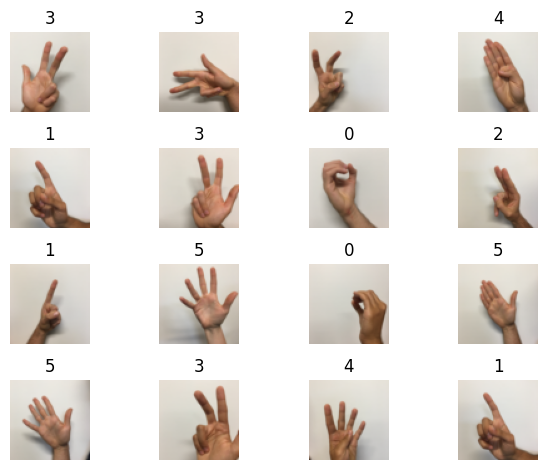

In [15]:
plt.figure()

predicted = clf.predict(X_test_scaled)

display_samples_in_grid(X_test, n_rows=4, y= predicted)


In [16]:
#plt.gcf().canvas.set_window_title('Test set prediction')

### Compare with SVM 

In [17]:
from sklearn.svm import SVC

In [18]:
clf = SVC(C=10, kernel='rbf', gamma=0.001).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test_scaled, y_test)))

train accuracy= 100.000%
test accuracy= 65.000%
